# 07 · Spatial-window LIANA rank aggregation

This notebook estimates ligand–receptor activity in overlapping adaptive spatial windows, collapses those windows to one edge vector per biological sample, and compares conditions at the sample level.

Configure the cell scope and ligand–receptor resource, audit the input, and run a small smoke test before launching the full resumable analysis.

In [17]:
import json
import os
import shlex
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import liana as li
from IPython.display import Image, Markdown, display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
SOURCE_ROOT = str(REPO_ROOT / "src")
if SOURCE_ROOT not in sys.path:
    sys.path.insert(0, SOURCE_ROOT)

from spatial_workflow.config import load_config, resolve_path
from spatial_workflow.liana_edge_features import top_edge_features
from spatial_workflow.liana_window import (
    WindowParameters,
    analyze_window_rankagg,
    audit_liana_input,
    liana_window_status,
    load_cellchat_resource,
    load_rankagg_resource,
    load_window_analysis,
    parameter_table,
    prepare_chord_input,
    render_chord,
    run_window_rankagg,
)
from spatial_workflow.liana_window_plotting import (
    plot_pathway_driver_summary,
    plot_pathway_ranking,
)

CONFIG_PATH = REPO_ROOT / "configs" / "local.yaml"
config = load_config(CONFIG_PATH)
schema = config["schema"]
results_root = resolve_path(CONFIG_PATH, config["paths"]["results_root"])
cellcharter = config["cellcharter"]
INPUT_H5AD = resolve_path(
    CONFIG_PATH,
    Path(cellcharter["output_dir"]) / f"{cellcharter['output_name']}.h5ad",
    root=results_root,
)
OUTPUT_DIR = results_root / "07_liana_window_rankagg"
ANALYSIS_DIR = OUTPUT_DIR / "analysis"
CELLCHAT_CSV = Path(
    os.environ.get(
        "CELLCHAT_CSV",
        REPO_ROOT / "resources" / "CellChatDB_interaction.csv",
    )
)
CHORD_SCRIPT = REPO_ROOT / "scripts" / "plot_liana_window_chord.R"

print("input:", INPUT_H5AD)
print("output:", OUTPUT_DIR)
print("CellChat:", CELLCHAT_CSV)

input: /path/to/spatial-workflow/results/ab_xenium/02_cellcharter/ab_xenium_cellcharter.h5ad
output: /path/to/spatial-workflow/results/ab_xenium/07_liana_window_rankagg
CellChat: /path/to/CellChatDB_interaction.csv


## Analysis scope and parameters

`CELL_TYPES` and `COMPARTMENTS` filter cells before windows are constructed. Choose a CellChat, custom, or native LIANA resource and optionally restrict pathways, annotations, or ligand–receptor pairs. For CellChat mode, set the `CELLCHAT_CSV` environment variable or edit `CELLCHAT_CSV` in the setup cell.

`WindowParameters` controls window size, expression support, spatial weighting, and LIANA permutations. Review the printed resource and parameter audits before running the analysis.

In [18]:
# None means all available values. These filters are applied before windows.
CELL_TYPES = None          # e.g. ["Astrocyte", "Microglia"]
COMPARTMENTS = None         # e.g. ["0", "3"]; selected domains are pooled

# LR_RESOURCE_MODE: "cellchat", "custom", or "liana".
LR_RESOURCE_MODE = "cellchat"
CUSTOM_LR_CSV = None        # CSV with ligand/receptor columns
LIANA_RESOURCE_NAME = "mouseconsensus"
LR_PATHWAYS = None          # pathway_name values; CellChat/annotated custom only
LR_ANNOTATIONS = None       # annotation values; CellChat/annotated custom only
LR_PAIRS = None             # exact ligand^receptor strings
INCLUDE_NON_PROTEIN = False # CellChat v2 default; True adds metabolic/synaptic rows
# Pathway annotation used downstream; for an annotated custom LR CSV,
# set this to CUSTOM_LR_CSV. Native mouseconsensus has no pathways, so
# the CellChat default annotates only its overlapping pairs.
PATHWAY_METADATA_CSV = CELLCHAT_CSV


PARAMETERS = WindowParameters(
    adaptive_k=60,
    grid_stride=100.0,
    expr_prop=0.1,
    min_cells=5,
    min_required_groups=2,
    spatial_bandwidth=250.0,
    spatial_kernel="gaussian",
    spatial_trim_fraction=0.1,
    n_perms=200,
    seed=1337,
    n_jobs=8,
    anchor_groups=(),
    anchor_k_target=60,
    anchor_min_cells=2,
    anchor_max_radius=150.0,
    anchor_dedup_distance=60.0,
    return_all_lrs=False,
)
display(parameter_table(PARAMETERS))

resource, resource_metadata = load_rankagg_resource(
    li,
    mode=LR_RESOURCE_MODE,
    cellchat_csv=CELLCHAT_CSV,
    custom_lr_csv=CUSTOM_LR_CSV,
    liana_resource_name=LIANA_RESOURCE_NAME,
    pathways=LR_PATHWAYS,
    annotations=LR_ANNOTATIONS,
    lr_pairs=LR_PAIRS,
    include_non_protein=INCLUDE_NON_PROTEIN,
)
display(
    pd.Series(
        {
            "selected resource metadata rows": len(resource_metadata),
            "distinct LIANA gene-complex tests": len(resource),
            "annotated pathways": resource_metadata["pathway_name"].nunique(),
            "annotations": resource_metadata["annotation"].nunique(),
        },
        name="resource audit",
    ).to_frame()
)

,parameter,default,meaning
0,adaptive_k,60,Nearest cells assigned to each adaptive grid c...
1,grid_stride,100.0,Spacing between candidate grid centers in spat...
2,expr_prop,0.1,Minimum within-group expression proportion for...
3,min_cells,5,Minimum cells in each LIANA source/target group.
4,min_required_groups,2,Groups with >= min_cells required for a valid ...
5,spatial_bandwidth,250.0,Gaussian proximity bandwidth passed to LIANA.
6,spatial_kernel,gaussian,Spatial proximity kernel passed to LIANA.
7,spatial_trim_fraction,0.1,Trim fraction for nearest-target spatial dista...
8,n_perms,200,LIANA within-window permutations.
9,seed,1337,LIANA/random seed.


,resource audit
selected resource metadata rows,2377
distinct LIANA gene-complex tests,2365
annotated pathways,254
annotations,3


## Input audit

This read-only check reports the samples, conditions, selected cells, and eligible annotations after applying the requested scope. Use it to catch missing or unexpectedly sparse groups before launching LIANA.

In [19]:
RUN_INPUT_AUDIT = True
if RUN_INPUT_AUDIT:
    input_audit = audit_liana_input(
        INPUT_H5AD,
        sample_key=schema["sample_key"],
        condition_key=schema["condition_key"],
        group_key=schema["cell_type_key"],
        spatial_key=schema["spatial_key"],
        compartment_key=schema.get("spatial_domain_key"),
        cell_types=CELL_TYPES,
        compartments=COMPARTMENTS,
    )
    display(input_audit["shape"].to_frame("value"))
    display(input_audit["samples"])
    display(input_audit["cell_groups"].head(50))

,value
cells_before_scope,870645
cells_after_scope,870645
genes,5006


,condition,sample_id,n_cells
0,naive_igg,naive_70_igg,75390
1,naive_igg,naive_72_igg,66468
2,naive_igg,naive_75_igg,75552
3,naive_igg,naive_77_igg,75666
4,vap_ab,vap_38_ab,72424
5,vap_ab,vap_41_ab,71229
6,vap_ab,vap_49_ab,68479
7,vap_ab,vap_52_ab,75306
8,vap_igg,vap_42_igg,65352
9,vap_igg,vap_46_igg,73211


,condition,cluster_sub,n_cells
0,naive_igg,AST_sub0,7875
1,naive_igg,AST_sub1,6723
2,naive_igg,AST_sub2,4511
3,naive_igg,AST_sub3,3892
4,naive_igg,AST_sub4,3372
5,naive_igg,AST_sub5,2761
6,naive_igg,AST_sub6,1407
7,naive_igg,AST_sub7,1720
8,naive_igg,AST_sub8,1443
9,naive_igg,AST_sub9,756


## Run or resume sample-level LIANA

This is the expensive stage. Outputs and manifests are written separately for each biological sample, allowing completed samples to be reused.

Use a small sample list or window limit only for a clean smoke-test directory. After reviewing the command preview, enable the run switch to create the resumable tmux job.

In [20]:
RUN_LIANA = False
LAUNCH_TMUX = False         # set True to detach the expensive run
TMUX_SESSION = "liana_window_rankagg"
TMUX_LOG = OUTPUT_DIR / "logs" / f"{TMUX_SESSION}.log"
SAMPLES = None             # e.g. ["vap_46_igg"] for a smoke test
LIMIT_WINDOWS = None       # e.g. 2 for smoke testing only
OVERWRITE_LIANA = False

def _append_repeated(arguments, flag, values):
    for value in values or []:
        arguments.extend([flag, str(value)])

cli_arguments = [
    sys.executable,
    str(REPO_ROOT / "scripts" / "run_liana_window_rankagg.py"),
    "--config",
    str(CONFIG_PATH),
    "run",
    "--input-h5ad",
    str(INPUT_H5AD),
    "--output-dir",
    str(OUTPUT_DIR),
    "--resource-mode",
    LR_RESOURCE_MODE,
    "--liana-resource-name",
    LIANA_RESOURCE_NAME,
    "--adaptive-k",
    str(PARAMETERS.adaptive_k),
    "--grid-stride",
    str(PARAMETERS.grid_stride),
    "--expr-prop",
    str(PARAMETERS.expr_prop),
    "--min-cells",
    str(PARAMETERS.min_cells),
    "--min-required-groups",
    str(PARAMETERS.min_required_groups),
    "--spatial-bandwidth",
    str(PARAMETERS.spatial_bandwidth),
    "--spatial-kernel",
    PARAMETERS.spatial_kernel,
    "--spatial-trim-fraction",
    str(PARAMETERS.spatial_trim_fraction),
    "--n-perms",
    str(PARAMETERS.n_perms),
    "--seed",
    str(PARAMETERS.seed),
    "--n-jobs",
    str(PARAMETERS.n_jobs),
    "--anchor-k-target",
    str(PARAMETERS.anchor_k_target),
    "--anchor-min-cells",
    str(PARAMETERS.anchor_min_cells),
    "--anchor-max-radius",
    str(PARAMETERS.anchor_max_radius),
    "--anchor-dedup-distance",
    str(PARAMETERS.anchor_dedup_distance),
]
if LR_RESOURCE_MODE == "cellchat":
    cli_arguments.extend(["--cellchat-csv", str(CELLCHAT_CSV)])
elif LR_RESOURCE_MODE == "custom":
    if CUSTOM_LR_CSV is None:
        raise ValueError("CUSTOM_LR_CSV is required for custom LR mode")
    cli_arguments.extend(["--custom-lr-csv", str(CUSTOM_LR_CSV)])
_append_repeated(cli_arguments, "--sample", SAMPLES)
_append_repeated(cli_arguments, "--cell-type", CELL_TYPES)
_append_repeated(cli_arguments, "--compartment", COMPARTMENTS)
_append_repeated(cli_arguments, "--pathway", LR_PATHWAYS)
_append_repeated(cli_arguments, "--annotation", LR_ANNOTATIONS)
_append_repeated(cli_arguments, "--lr-pair", LR_PAIRS)
_append_repeated(cli_arguments, "--anchor-group", PARAMETERS.anchor_groups)
if INCLUDE_NON_PROTEIN:
    cli_arguments.append("--include-non-protein")
if PARAMETERS.return_all_lrs:
    cli_arguments.append("--return-all-lrs")
if OVERWRITE_LIANA:
    cli_arguments.append("--overwrite")
if LIMIT_WINDOWS is not None:
    cli_arguments.extend(["--limit-windows-per-sample", str(LIMIT_WINDOWS)])

print("CLI preview:", shlex.join(cli_arguments))
if RUN_LIANA and LAUNCH_TMUX:
    TMUX_LOG.parent.mkdir(parents=True, exist_ok=True)
    session_exists = subprocess.run(
        ["tmux", "has-session", "-t", TMUX_SESSION],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        check=False,
    ).returncode == 0
    if session_exists:
        raise RuntimeError(f"tmux session already exists: {TMUX_SESSION}")
    shell_command = (
        f"cd {shlex.quote(str(REPO_ROOT))} && "
        f"{shlex.join(cli_arguments)} 2>&1 | tee {shlex.quote(str(TMUX_LOG))}"
    )
    subprocess.run(
        ["tmux", "new-session", "-d", "-s", TMUX_SESSION, "bash", "-lc", shell_command],
        check=True,
    )
    display(pd.Series({
        "tmux_session": TMUX_SESSION,
        "log": str(TMUX_LOG),
        "attach": f"tmux attach -t {TMUX_SESSION}",
    }))
elif RUN_LIANA:
    run_status = run_window_rankagg(
        INPUT_H5AD,
        CELLCHAT_CSV,
        OUTPUT_DIR,
        sample_key=schema["sample_key"],
        condition_key=schema["condition_key"],
        group_key=schema["cell_type_key"],
        spatial_key=schema["spatial_key"],
        compartment_key=schema.get("spatial_domain_key"),
        cell_types=CELL_TYPES,
        compartments=COMPARTMENTS,
        pathways=LR_PATHWAYS,
        annotations=LR_ANNOTATIONS,
        lr_pairs=LR_PAIRS,
        resource_mode=LR_RESOURCE_MODE,
        custom_lr_csv=CUSTOM_LR_CSV,
        liana_resource_name=LIANA_RESOURCE_NAME,
        include_non_protein=INCLUDE_NON_PROTEIN,
        parameters=PARAMETERS,
        samples=SAMPLES,
        overwrite=OVERWRITE_LIANA,
        limit_windows_per_sample=LIMIT_WINDOWS,
    )
    display(run_status)
else:
    print("Set RUN_LIANA=True; use LAUNCH_TMUX=True for a detached run.")

artifact_status = liana_window_status(OUTPUT_DIR)
display(artifact_status if not artifact_status.empty else pd.DataFrame(
    {"status": ["No completed sample manifests yet"]}
))

CLI preview: python /path/to/spatial-workflow/scripts/run_liana_window_rankagg.py --config /path/to/spatial-workflow/configs/local.yaml run --input-h5ad /path/to/spatial-workflow/results/ab_xenium/02_cellcharter/ab_xenium_cellcharter.h5ad --output-dir /path/to/spatial-workflow/results/ab_xenium/07_liana_window_rankagg --resource-mode cellchat --liana-resource-name mouseconsensus --adaptive-k 60 --grid-stride 100.0 --expr-prop 0.1 --min-cells 5 --min-required-groups 2 --spatial-bandwidth 250.0 --spatial-kernel gaussian --spatial-trim-fraction 0.1 --n-perms 200 --seed 1337 --n-jobs 8 --anchor-k-target 60 --anchor-min-cells 2 --anchor-max-radius 150.0 --anchor-dedup-distance 60.0 --cellchat-csv /path/to/CellChatDB_interaction.csv
Set RUN_LIANA=True; LAUNCH_TMUX=True is the default execution mode.


,sample,condition,status,merged_output_exists,n_valid_windows,n_failed_windows,n_merged_edges,manifest
0,naive_70_igg,naive_igg,complete,True,3600,0,214314,/path/to/project-data/spatial-work...
1,naive_72_igg,naive_igg,complete,True,3443,0,217927,/path/to/project-data/spatial-work...
2,naive_75_igg,naive_igg,complete,True,3634,0,229559,/path/to/project-data/spatial-work...
3,naive_77_igg,naive_igg,complete,True,2932,0,218661,/path/to/project-data/spatial-work...
4,vap_38_ab,vap_ab,complete,True,2948,0,226200,/path/to/project-data/spatial-work...
5,vap_41_ab,vap_ab,complete,True,3083,0,220903,/path/to/project-data/spatial-work...
6,vap_42_igg,vap_igg,complete,True,2992,0,195671,/path/to/project-data/spatial-work...
7,vap_46_igg,vap_igg,complete,True,3105,0,216953,/path/to/project-data/spatial-work...
8,vap_49_ab,vap_ab,complete,True,3416,0,206050,/path/to/project-data/spatial-work...
9,vap_50_igg,vap_igg,complete,True,2869,0,206219,/path/to/project-data/spatial-work...


## Build the tested edge universe

The analysis first defines supported source–target–ligand–receptor edges across samples, then completes missing edge–sample combinations with the configured inactive value before calculating condition statistics.

The displayed audit records support thresholds, zero filling, contrasts, and the exact permutation resolution so each tested edge can be interpreted reproducibly.

In [21]:
CONDITIONS = ["naive_igg", "vap_igg", "vap_ab"]
MIN_CONDITION_SAMPLES = 3
RANK_COLUMN = "magnitude_rank"
ZERO_FILL_MISSING = True   # default; False uses observed/complete cases
RUN_PAIRWISE_ANALYSIS = False
OVERWRITE_ANALYSIS = False

if RUN_PAIRWISE_ANALYSIS:
    analysis_tables = analyze_window_rankagg(
        OUTPUT_DIR,
        PATHWAY_METADATA_CSV,
        ANALYSIS_DIR,
        conditions=CONDITIONS,
        min_condition_samples=MIN_CONDITION_SAMPLES,
        rank_column=RANK_COLUMN,
        zero_fill_missing=ZERO_FILL_MISSING,
        include_non_protein=INCLUDE_NON_PROTEIN,
        overwrite=OVERWRITE_ANALYSIS,
    )
    display(
        pd.Series(
            {name: table.shape for name, table in analysis_tables.items()},
            name="shape",
        ).to_frame()
    )
else:
    print("Set RUN_PAIRWISE_ANALYSIS=True after all intended samples finish.")

Set RUN_PAIRWISE_ANALYSIS=True after all intended samples finish.


## Review edge-level changes

Each row is one source–target–ligand–receptor edge for one contrast. `mean_activity_a` and `mean_activity_b` average its sample-level activity within each condition, and `difference_b_minus_a` is the signed effect: positive values indicate higher activity in condition B.

- `exact_permutation_p` is a two-sided exhaustive reassignment of biological-sample condition labels for that mean difference. It does not treat windows or cells as replicates. The value is raw; `exact_permutation_q` is the Benjamini–Hochberg adjustment across tested edges in the contrast.
- `welch_p` is the two-sided Welch t-test on the same sample-level activities and allows unequal condition variances; `welch_q` is its Benjamini–Hochberg adjustment. With few samples, use the exact test as the primary small-sample result and Welch as a complementary parametric check.
- `presence_class` and the observed-sample counts describe whether LIANA emitted the edge with adequate support in both conditions or whether it appeared, disappeared, or was sparse. They describe support, not statistical significance.

With four samples per condition, the minimum attainable two-sided exact p-value is `0.02857`. Interpret p-values together with effect direction, magnitude, support, and the missing-edge policy.

In [22]:
analysis_tables = load_window_analysis(ANALYSIS_DIR) if (
    ANALYSIS_DIR / "manifest.json"
).exists() else None

if analysis_tables is not None:
    edge_pairwise = analysis_tables["edge_pairwise"]
    selected_contrast = edge_pairwise["contrast"].iloc[0]
    edge_review = edge_pairwise[
        edge_pairwise["contrast"].eq(selected_contrast)
        & edge_pairwise["tested"]
    ].sort_values(
        ["exact_permutation_p", "abs_difference"],
        ascending=[True, False],
    )
    display(edge_review.head(50))
    display(
        edge_review.groupby("presence_class", observed=True)
        .agg(
            n_edges=("edge_id", "nunique"),
            median_abs_difference=("abs_difference", "median"),
            raw_p_lt_0_05=("exact_permutation_p", lambda x: (x < 0.05).sum()),
            fdr_q_lt_0_05=("exact_permutation_q", lambda x: (x < 0.05).sum()),
        )
        .sort_values("n_edges", ascending=False)
    )
else:
    print("Analysis tables are not present yet.")

,edge_id,lr_id,pathway_id,source,target,ligand_complex,receptor_complex,ligand,receptor,pathway_name,...,difference_b_minus_a,abs_difference,higher_condition,welch_t,welch_p,exact_permutation_p,welch_q,exact_permutation_q,exact_partitions,minimum_attainable_p
65677,E0184552,LR00734,PW0113,EX-HB,OLIG_sub9,Ncam1,Fgfr1,Ncam1,Fgfr1,NCAM,...,-0.805500,0.805500,naive_igg,-7.616408,0.004698,0.028571,0.737871,1.0,70.0,0.028571
40533,E0127000,LR00024,PW0015,ChP,OLIG_sub0,App,Sorl1,App,Sorl1,APP,...,-0.708518,0.708518,naive_igg,-5.467164,0.002006,0.028571,0.737871,1.0,70.0,0.028571
40540,E0127046,LR00168,PW0041,ChP,OLIG_sub0,Cntn2,Cntn2,Cntn2,Cntn2,CNTN,...,-0.698102,0.698102,naive_igg,-5.815409,0.003316,0.028571,0.737871,1.0,70.0,0.028571
40554,E0127126,LR00444,PW0068,ChP,OLIG_sub0,Gas6,Tyro3,Gas6,Tyro3,GAS,...,-0.674333,0.674333,naive_igg,-4.265584,0.005512,0.028571,0.737871,1.0,70.0,0.028571
40583,E0127223,LR00719,PW0107,ChP,OLIG_sub0,Mag,Mag,Mag,Mag,MAG,...,-0.639659,0.639659,naive_igg,-4.690982,0.003482,0.028571,0.737871,1.0,70.0,0.028571
65635,E0184390,LR00001,PW0129,EX-HB,OLIG_sub9,Adcyap1,Adcyap1r1,Adcyap1,Adcyap1r1,PACAP,...,-0.622968,0.622968,naive_igg,-3.697446,0.034339,0.028571,0.737871,1.0,70.0,0.028571
40586,E0127234,LR00736,PW0113,ChP,OLIG_sub0,Ncam1,Ncam1,Ncam1,Ncam1,NCAM,...,-0.618826,0.618826,naive_igg,-6.773507,0.006576,0.028571,0.737871,1.0,70.0,0.028571
192391,E0548326,LR00668,PW0099,PVF,AST_sub5,Lamb2,Dag1,Lamb2,Dag1,LAMININ,...,0.611706,0.611706,vap_igg,2.813456,0.067100,0.028571,0.737871,1.0,70.0,0.028571
192410,E0548362,LR00725,PW0110,PVF,AST_sub5,Mdk,Ptprz1,Mdk,Ptprz1,MK,...,0.608767,0.608767,vap_igg,2.802697,0.067701,0.028571,0.737871,1.0,70.0,0.028571
65637,E0184404,LR00089,PW0023,EX-HB,OLIG_sub9,Cadm1,Cadm1,Cadm1,Cadm1,CADM,...,-0.606567,0.606567,naive_igg,-4.158334,0.025290,0.028571,0.737871,1.0,70.0,0.028571


,n_edges,median_abs_difference,raw_p_lt_0_05,fdr_q_lt_0_05
presence_class,,,,
supported_both,116920,0.022359,1762,0
a_supported_b_sparse,33498,0.017303,207,0
b_supported_a_sparse,26389,0.019893,124,0
disappears_in_b,4675,0.000000,37,0
appears_in_b,3293,0.000000,8,0


## Summarize significant edge features

For a selected contrast and exact-p threshold, this section counts significant ligands, receptors, ligand–receptor pairs, pathways, sources, targets, and source–target pairs. Counts refer to unique tested edges.

In [23]:
EDGE_FEATURE_CONTRASTS = (
    "vap_igg_vs_naive_igg",
    "vap_ab_vs_vap_igg",
)
EDGE_FEATURE_THRESHOLD = 0.05
EDGE_FEATURE_TOP_N = 20

edge_feature_tables_by_contrast = None
if analysis_tables is not None:
    edge_feature_tables_by_contrast = {}
    for contrast in EDGE_FEATURE_CONTRASTS:
        display(Markdown(f"### {contrast}"))
        feature_tables = top_edge_features(
            analysis_tables["edge_pairwise"],
            contrast=contrast,
            threshold=EDGE_FEATURE_THRESHOLD,
            top_n=EDGE_FEATURE_TOP_N,
        )
        edge_feature_tables_by_contrast[contrast] = feature_tables
        for table_name, table in feature_tables.items():
            display(Markdown(f"#### {table_name.replace("_", " ").title()}"))
            display(table)
else:
    print("Analysis tables are not present yet.")

### vap_igg_vs_naive_igg

#### Ligands

,ligand_complex,n_significant_edges
0,Lamc1,88
1,Lamb2,71
2,Mdk,66
3,Ncam1,52
4,Wnt7b,50
5,Jam2,39
6,Cntn1,38
7,Efnb3,36
8,Lama2,36
9,Lama5,36


#### Receptors

,receptor_complex,n_significant_edges
0,Itgav_Itgb8,99
1,Itga3_Itgb1,79
2,Dag1,73
3,Sv2a,60
4,Fgfr1,55
5,Itga9_Itgb1,49
6,Notch2,49
7,Notch1,40
8,Epha4,37
9,Fgfr2,34


...

,source,n_significant_edges
0,PVF,326
1,EC,317
2,IN-GABA-HT-AMY,196
3,OLIG_sub0,149
4,EX-TH,121
5,EX-L23-IT,118
6,EPD,79
7,AST_sub1,70
8,MSN-D1,69
9,AST_sub2,60


#### Targets

,target,n_significant_edges
0,EC,208
1,PVF,162
2,MG,116
3,AST_sub2,101
4,EX-TH,87
5,OPC,85
6,MSN-D1,79
7,AST_sub1,75
8,EPD,73
9,IN-GABA-HT-AMY,67


#### Source Target Pairs

,source,target,n_significant_edges
0,EC,AST_sub2,49
1,EC,EX-TH,43
2,PVF,EPD,43
3,PVF,MSN-D1,42
4,PVF,ChP,39
5,EC,OLIG_sub4,32
6,PVF,PVF,28
7,EC,PERICYTE,27
8,IN-GABA-HT-AMY,EX-HB,26
9,EC,EC,25


## Rank pathway changes

Pathways are ranked by `rms_centroid_distance` after requiring either pathway-level exact p-value to pass the selected threshold.

- `mean_activity_exact_p` first averages all eligible pathway edges within each sample, then exhaustively reassigns the biological-sample condition labels and tests `mean_activity_difference_b_minus_a`, the difference between condition means. It is most sensitive to a coherent overall increase or decrease across the pathway.
- `rms_centroid_distance` is the root-mean-square difference between the two condition mean activity vectors across the pathway's edges. It is an unsigned effect size, so large increases and decreases cannot cancel each other.
- `rms_exact_p` exhaustively reassigns the sample labels and asks how often the resulting RMS centroid distance is at least as large as the observed distance. It detects a change in the pathway's multiedge signaling profile even when the average pathway activity changes little.

Both exact p-values use biological samples as replicates and are raw; `mean_activity_exact_q` and `rms_exact_q` are their Benjamini–Hochberg adjustments across pathways in the contrast. Use the bar chart to select a pathway, then inspect its contributing ligand–receptor identities and directed cell-pair edges below.

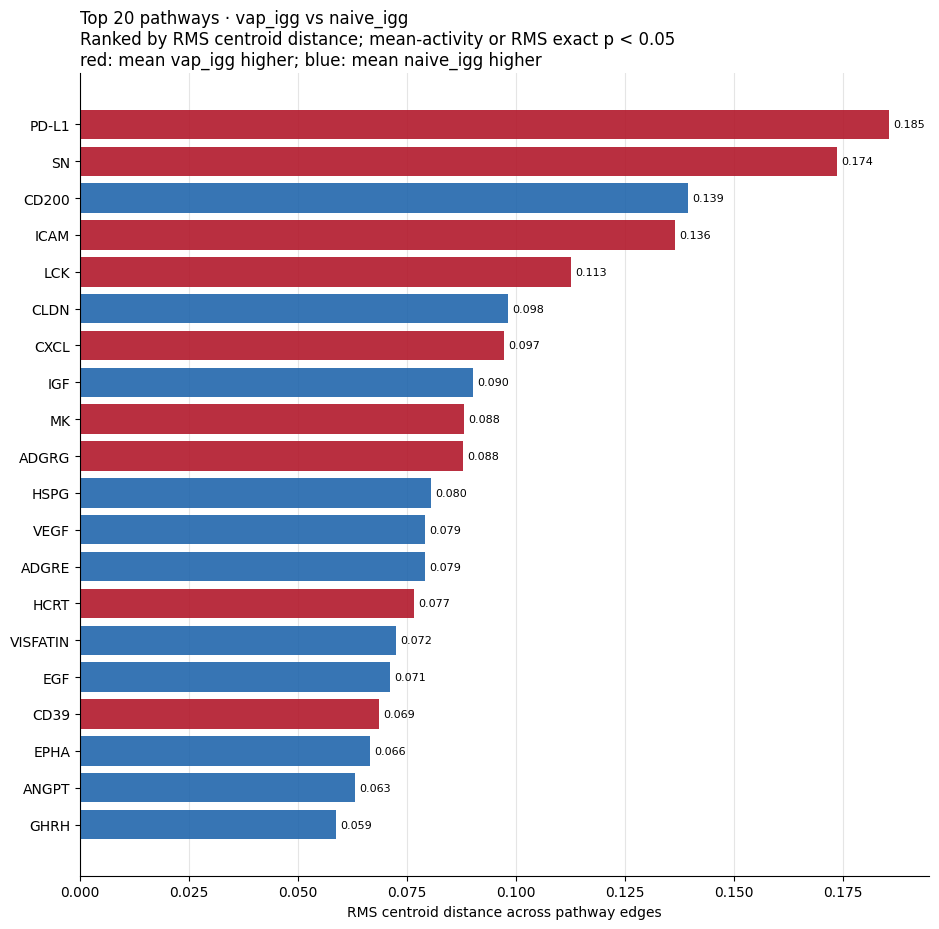

,display_rank,pathway_name,mean_activity_difference_b_minus_a,mean_activity_exact_p,rms_centroid_distance,rms_exact_p
0,1,PD-L1,0.138780,0.028571,0.185489,0.057143
1,2,SN,0.133424,0.057143,0.173684,0.028571
2,3,CD200,-0.027828,0.171429,0.139409,0.028571
3,4,ICAM,0.075948,0.028571,0.136440,0.028571
4,5,LCK,0.071283,0.057143,0.112534,0.028571
5,6,CLDN,-0.031047,0.057143,0.098139,0.028571
6,7,CXCL,0.013516,0.142857,0.097200,0.028571
7,8,IGF,-0.007116,0.200000,0.090144,0.028571
8,9,MK,0.004638,0.371429,0.088040,0.028571
9,10,ADGRG,0.002356,0.542857,0.087847,0.028571


In [3]:
# Ranking options: rms_centroid_distance, rms_exact_p, mean_activity_exact_p,
# or mean_activity_difference_b_minus_a.
PATHWAY_RANK_BY = "rms_centroid_distance"
PATHWAY_TOP_N = 20
PATHWAY_EXACT_P_MAX = 0.05  # mean-activity OR RMS exact p must be below this

if analysis_tables is not None:
    pathway_pairwise = analysis_tables["pathway_pairwise"]
    pathway_rank_figure, pathway_rank_axis, pathway_review = plot_pathway_ranking(
        pathway_pairwise,
        contrast=selected_contrast,
        rank_by=PATHWAY_RANK_BY,
        top_n=PATHWAY_TOP_N,
        exact_p_max=PATHWAY_EXACT_P_MAX,
    )
    selected_pathway = pathway_review.iloc[0]["pathway_name"]
    display(pathway_rank_figure)
    plt.close(pathway_rank_figure)

    pathway_columns = [
        "display_rank", "pathway_name", "mean_activity_difference_b_minus_a",
        "mean_activity_exact_p", "rms_centroid_distance", "rms_exact_p",
    ]
    display(pathway_review[pathway_columns])
else:
    print("Analysis tables are not present yet.")

## Inspect one pathway

The driver bars group the pathway's directed cell-pair edges by ligand–receptor identity. **Share of absolute effect** is `100 × sum(abs(edge difference))` for that ligand–receptor pair divided by the same sum over every edge in the pathway. It therefore measures how much of the pathway's total change magnitude is carried by that pair—not its statistical significance or direction. Shares across all pathway drivers sum to 100%; a top-N display may sum to less.

`signed_effect_sum` gives the net direction, while `direction_balance` divides the signed sum by the absolute sum: `+1` means all contributing edges increase in condition B, `-1` means all decrease, and values near zero indicate cancellation. The adjacent bubble plot shows the individual source-to-target edges, with color encoding signed activity change and size encoding edge-level significance.

Change the selected pathway and contrast in the control cell, then rerun this section.

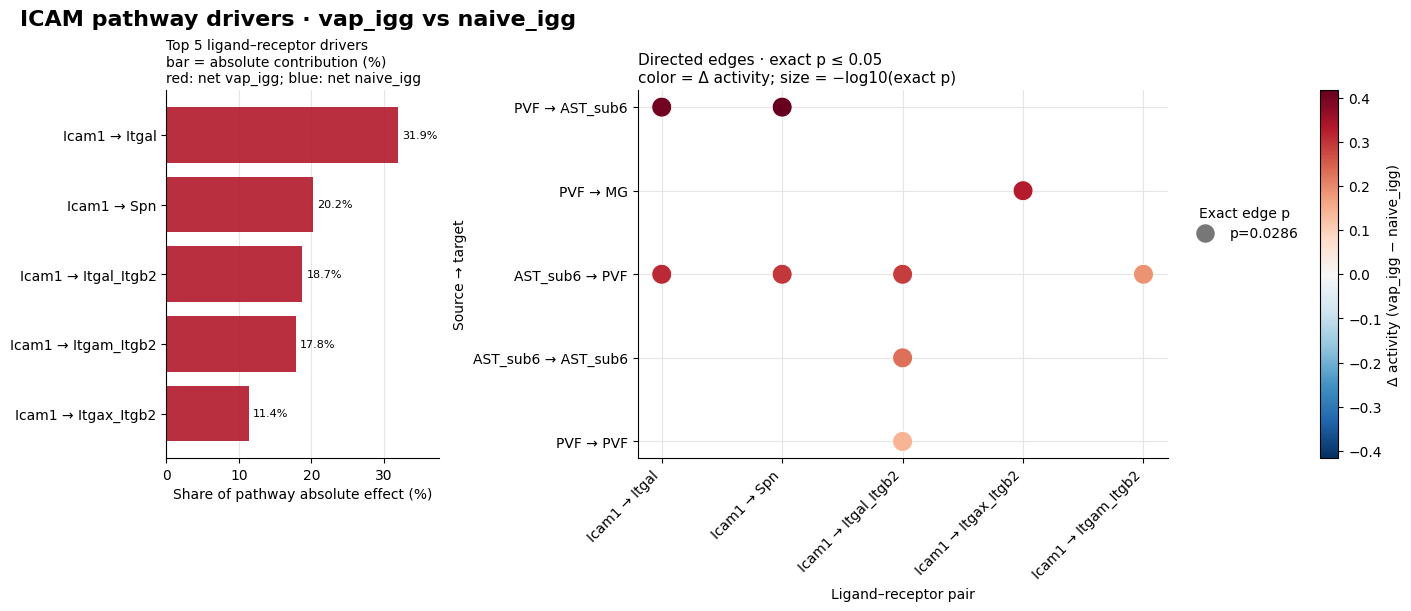

,lr_label,absolute_effect_percent,signed_effect_sum,direction_balance
0,Icam1 → Itgal,31.867106,2.665834,0.896003
1,Icam1 → Spn,20.176824,1.787400,0.948829
2,Icam1 → Itgal_Itgb2,18.741940,1.676972,0.958363
3,Icam1 → Itgam_Itgb2,17.846552,1.377114,0.826484
4,Icam1 → Itgax_Itgb2,11.367578,0.998910,0.941191


,source,target,ligand,receptor,difference_b_minus_a,exact_permutation_p,exact_permutation_q,presence_class
0,PVF,AST_sub6,Icam1,Spn,0.416600,0.028571,1.0,appears_in_b
1,PVF,AST_sub6,Icam1,Itgal,0.403129,0.028571,1.0,supported_both
2,PVF,MG,Icam1,Itgax_Itgb2,0.327516,0.028571,1.0,supported_both
3,AST_sub6,PVF,Icam1,Itgal,0.312243,0.028571,1.0,b_supported_a_sparse
4,AST_sub6,PVF,Icam1,Spn,0.293982,0.028571,1.0,b_supported_a_sparse
5,AST_sub6,PVF,Icam1,Itgal_Itgb2,0.289505,0.028571,1.0,b_supported_a_sparse
6,AST_sub6,AST_sub6,Icam1,Itgal_Itgb2,0.230768,0.028571,1.0,b_supported_a_sparse
7,AST_sub6,PVF,Icam1,Itgam_Itgb2,0.188409,0.028571,1.0,b_supported_a_sparse
8,PVF,PVF,Icam1,Itgal_Itgb2,0.141704,0.028571,1.0,supported_both


Selected pathway: ICAM


In [ ]:
SELECTED_PATHWAY = "ICAM"  # set to None to use the top-ranked pathway
DRIVER_TOP_N_LR = 15
DRIVER_TOP_N_EDGES = 35
DRIVER_EDGE_P_MAX = 0.05  # set to None to rank without an edge-level p filter

if analysis_tables is not None:
    pathway_name = SELECTED_PATHWAY or selected_pathway
    driver_figure, driver_axes, pathway_lr_review, pathway_edge_review = (
        plot_pathway_driver_summary(
            analysis_tables["pathway_edge_drivers"],
            contrast=selected_contrast,
            pathway=pathway_name,
            top_n_lr=DRIVER_TOP_N_LR,
            top_n_edges=DRIVER_TOP_N_EDGES,
            edge_exact_p_max=DRIVER_EDGE_P_MAX,
        )
    )
    display(driver_figure)
    plt.close(driver_figure)

    lr_columns = [
        "lr_label", "absolute_effect_percent", "signed_effect_sum", "direction_balance"
    ]
    edge_columns = [
        "source", "target", "ligand", "receptor", "difference_b_minus_a",
        "exact_permutation_p", "exact_permutation_q", "presence_class",
    ]
    display(pathway_lr_review[lr_columns])
    display(pathway_edge_review[edge_columns])
    print("Selected pathway:", selected_pathway)
else:
    print("Analysis tables are not present yet.")

## Directional chord plot

The chord diagram summarizes the selected pathway's directed cell–cell signaling edges. It uses the same pathway and contrast controls as the driver and bubble plots.

Rerun the rendering cell after changing the pathway; the title and output file are generated from the active selection.

In [ ]:
RENDER_RESULT_CHORD = True
CHORD_TOP_N = 15
if RENDER_RESULT_CHORD:
    if analysis_tables is None:
        raise RuntimeError("Run or load the pairwise analysis before rendering a chord")
    chord_input = prepare_chord_input(
        analysis_tables["pathway_edge_drivers"],
        contrast=selected_contrast,
        pathway_name=selected_pathway,
        top_n=CHORD_TOP_N,
    )
    chord_dir = ANALYSIS_DIR / "figures/chords"
    rendered = render_chord(
        chord_input,
        script_path=CHORD_SCRIPT,
        input_csv=chord_dir / f"{selected_contrast}__{selected_pathway}.csv",
        output_path=chord_dir / f"{selected_contrast}__{selected_pathway}.png",
        title=f"{selected_pathway}: {selected_contrast}",
        rscript_bin=config.get("runtime", {}).get("rscript_bin", "Rscript"),
    )
    display(Image(filename=str(rendered), width=900))
else:
    example_plot = REPO_ROOT / "docs/figures/liana_window_rankagg_example_chord.png"
    if example_plot.exists():
        display(Image(filename=str(example_plot), width=900))
    else:
        print("Example chord has not been rendered yet:", example_plot)

## Interpretation notes

- Biological samples, not spatial windows or cells, are the statistical replicates.
- Overlapping windows change spatial weighting but do not increase sample size.
- A completed inactive edge represents an interaction not emitted under the configured gates, not proof of literal biological absence.
- Pathway and edge results should be interpreted with their support counts and attainable exact-p resolution.